In [124]:
import pandas as pd
import numpy as np


df = pd.read_csv('/home/moosaabbasi/Downloads/petrol_consumption.csv')
print(df.head())
print(df.columns)

   Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)  \
0         9.0            3571            1976                         0.525   
1         9.0            4092            1250                         0.572   
2         9.0            3865            1586                         0.580   
3         7.5            4870            2351                         0.529   
4         8.0            4399             431                         0.544   

   Petrol_Consumption  
0                 541  
1                 524  
2                 561  
3                 414  
4                 410  
Index(['Petrol_tax', 'Average_income', 'Paved_Highways',
       'Population_Driver_licence(%)', 'Petrol_Consumption'],
      dtype='str')


In [125]:
df.describe

<bound method NDFrame.describe of     Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)  \
0         9.00            3571            1976                         0.525   
1         9.00            4092            1250                         0.572   
2         9.00            3865            1586                         0.580   
3         7.50            4870            2351                         0.529   
4         8.00            4399             431                         0.544   
5        10.00            5342            1333                         0.571   
6         8.00            5319           11868                         0.451   
7         8.00            5126            2138                         0.553   
8         8.00            4447            8577                         0.529   
9         7.00            4512            8507                         0.552   
10        8.00            4391            5939                         0.530   
11    

In [126]:
df.isnull().sum()

Petrol_tax                      0
Average_income                  0
Paved_Highways                  0
Population_Driver_licence(%)    0
Petrol_Consumption              0
dtype: int64

In [127]:
df.shape

(48, 5)

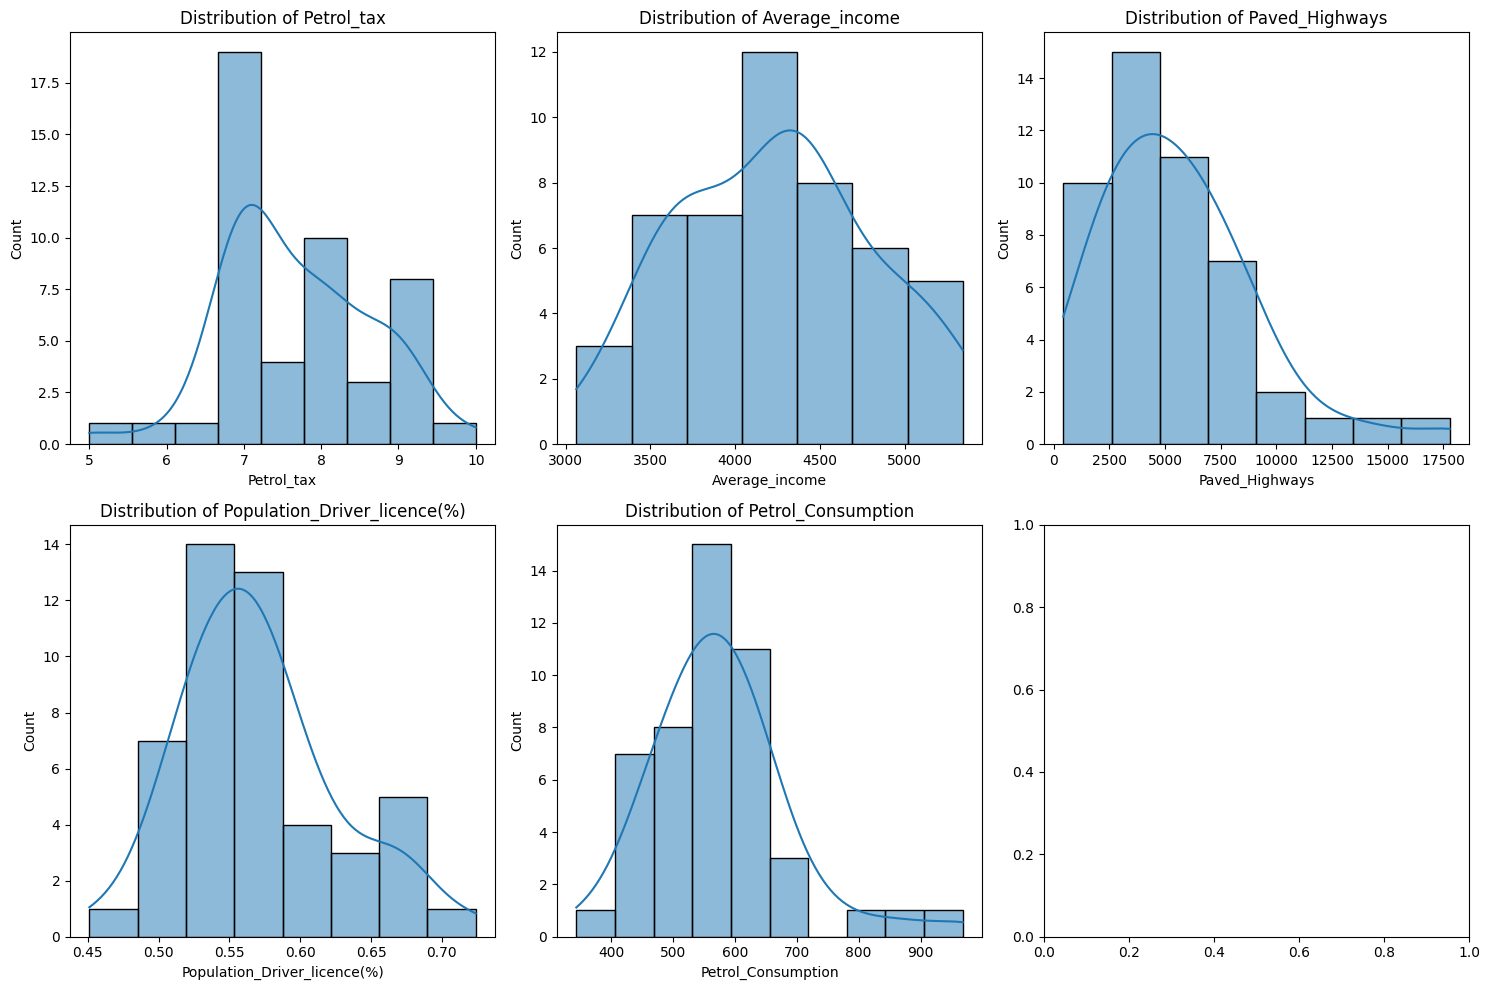

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

col = ['Petrol_tax', 'Average_income', 'Paved_Highways',
       'Population_Driver_licence(%)', 'Petrol_Consumption']

# Create a 2x3 grid of empty plots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten() # Flattens the grid to make looping easier

# Loop through the columns and plot each one in its own space
for i, column in enumerate(col):
    sns.histplot(data=df, x=column, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')

plt.tight_layout() # Cleans up the spacing between plots
plt.show()

<Axes: >

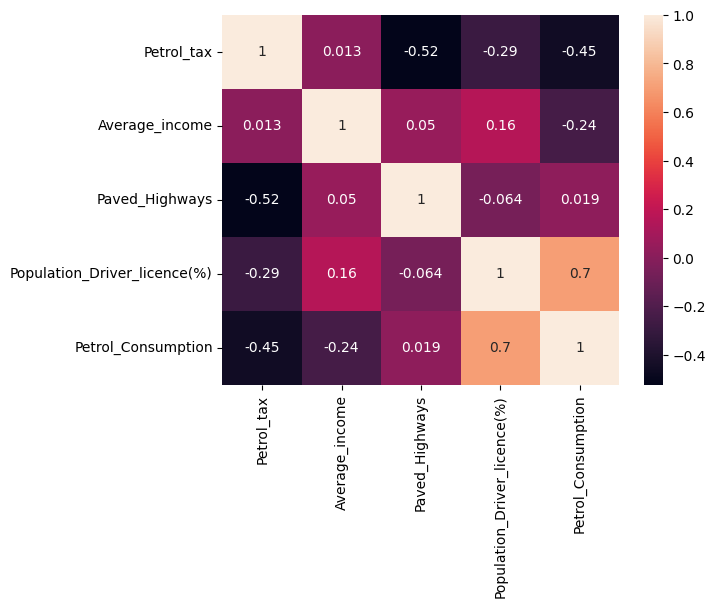

In [129]:
sns.heatmap(df.corr(),annot=True)

In [130]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
df_scale = df.copy()
df_scale1 = scale.fit_transform(df_scale)



In [131]:
df_scale = pd.DataFrame(df_scale1,columns=df.columns)
print(df_scale.head())

   Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)  \
0    1.415441       -1.181841       -1.038921                     -0.825903   
1    1.415441       -0.263969       -1.249055                      0.030364   
2    1.415441       -0.663887       -1.151803                      0.176112   
3   -0.178923        1.106673       -0.930381                     -0.753029   
4    0.352532        0.276889       -1.486106                     -0.479753   

   Petrol_Consumption  
0           -0.323092  
1           -0.476640  
2           -0.142446  
3           -1.470189  
4           -1.506318  


In [132]:
df_scale=df_scale.round(3)
print(df_scale.head())

   Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)  \
0       1.415          -1.182          -1.039                        -0.826   
1       1.415          -0.264          -1.249                         0.030   
2       1.415          -0.664          -1.152                         0.176   
3      -0.179           1.107          -0.930                        -0.753   
4       0.353           0.277          -1.486                        -0.480   

   Petrol_Consumption  
0              -0.323  
1              -0.477  
2              -0.142  
3              -1.470  
4              -1.506  


In [133]:
X = df_scale.iloc[:,:-1]
y = df_scale.iloc[:,-1:]

print(X.head())
print(y.head())


   Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)
0       1.415          -1.182          -1.039                        -0.826
1       1.415          -0.264          -1.249                         0.030
2       1.415          -0.664          -1.152                         0.176
3      -0.179           1.107          -0.930                        -0.753
4       0.353           0.277          -1.486                        -0.480
   Petrol_Consumption
0              -0.323
1              -0.477
2              -0.142
3              -1.470
4              -1.506


In [134]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [135]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [136]:
predict_X = model.predict(X_test)

print(f"predict value {predict_X[:5].round(3)}")
print(f"actual value {y_test[:5].round(3)}")

predict value [[ 0.162]
 [ 0.733]
 [ 0.018]
 [ 0.007]
 [-0.471]]
actual value     Petrol_Consumption
27               0.490
40               0.092
26               0.002
43               0.129
24              -1.055


/tmp/ipykernel_297194/1336652117.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , 'k--', color='red', lw=2)


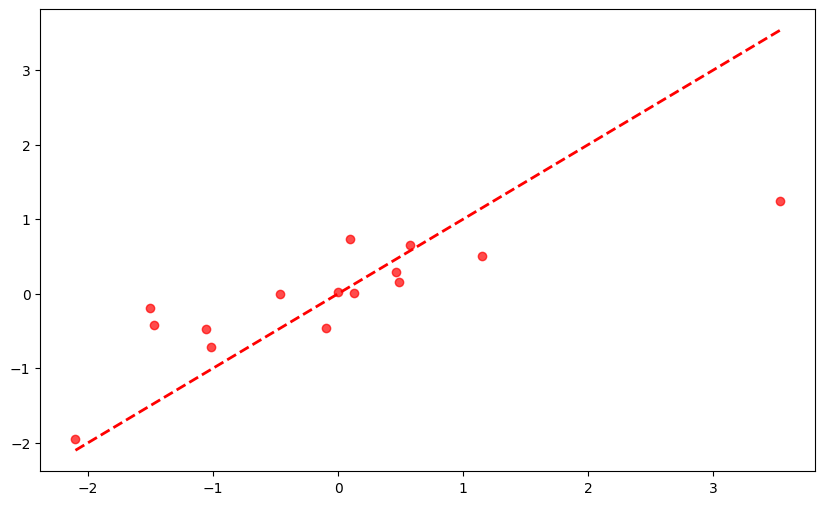

In [137]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,predict_X , color='red' , alpha=0.7)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , 'k--', color='red', lw=2)

In [138]:
print(f"intercpet {model.intercept_}")
print(f"coffecient {model.coef_}")

intercpet [0.01421576]
coffecient [[-0.33954379 -0.23261221 -0.15475969  0.51400024]]


In [139]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

mse = mean_squared_error(y_test,predict_X)
mae = mean_absolute_error(y_test,predict_X)
r2 = r2_score(y_test,predict_X)


print(f" mean_squared_error {mse}")
print(f" mean_absolute_error {mae}")
print(f"r2_score {r2}")

 mean_squared_error 0.6591773609968776
 mean_absolute_error 0.5694213832236108
r2_score 0.6157402574003334
